# 04 — Compare MDMp vs MDMr results

Merge Python and R outputs, run the **zero-matrix adjacency diff test**, and
summarize metrics and computation time.

> **Interpretation:** an exact zero-matrix match (`R_adj − Python_adj = 0`) is the
> strictest criterion. A few disagreements are not necessarily bugs — greedy HC
> can hit score ties / Markov-equivalent orientations, and small floating-point
> differences in the LPL can flip a near-tied move. Flag disagreements for
> inspection rather than treating them as automatic failures.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from helpers import DAGS, NODE_NAMES, N_REPLICATIONS, long_to_adjacency

DATA_DIR = "data/"
sns.set_palette("husl")

## 1. Sanity check — orientation and node order

Reconstruct adjacency matrices for `dag=3var`, `dataset_id=1` and verify
row = parent, col = child on both sides.

In [2]:
py_adj_df = pd.read_csv(os.path.join(DATA_DIR, "python_adjacency.csv"))
r_adj_df = pd.read_csv(os.path.join(DATA_DIR, "r_adjacency.csv"))
py_metrics = pd.read_csv(os.path.join(DATA_DIR, "python_metrics.csv"))
r_metrics = pd.read_csv(os.path.join(DATA_DIR, "r_metrics.csv"))

dag = "3var"
dataset_id = 1
node_names = NODE_NAMES[dag]

py_adj = long_to_adjacency(py_adj_df, dataset_id, dag)
r_adj = long_to_adjacency(r_adj_df, dataset_id, dag)

py_labeled = pd.DataFrame(py_adj, index=node_names, columns=node_names)
r_labeled = pd.DataFrame(r_adj, index=node_names, columns=node_names)

print("Python adjacency (row=parent, col=child):")
display(py_labeled)
print("\nR adjacency (row=parent, col=child):")
display(r_labeled)

assert list(py_labeled.index) == list(r_labeled.index), "Node order mismatch (rows)"
assert list(py_labeled.columns) == list(r_labeled.columns), "Node order mismatch (cols)"
print("\nNode ordering matches. Orientation convention: row=parent, col=child.")

Python adjacency (row=parent, col=child):


,Y1,Y2,Y3
Y1,0,1,0
Y2,0,0,1
Y3,0,0,0



R adjacency (row=parent, col=child):


,Y1,Y2,Y3
Y1,0,1,0
Y2,0,0,1
Y3,0,0,0



Node ordering matches. Orientation convention: row=parent, col=child.


## 2. Zero-matrix test — `R_adj − Python_adj`

For every `(dag, dataset_id)`, compute the element-wise difference. A perfect
match yields an all-zeros matrix.

In [3]:
diff_records = []
heatmap_accum = {dag: None for dag in DAGS}

for dag in DAGS:
    node_names = NODE_NAMES[dag]
    n = len(node_names)
    heatmap_accum[dag] = np.zeros((n, n), dtype=int)

    for dataset_id in range(1, N_REPLICATIONS + 1):
        py_adj = long_to_adjacency(py_adj_df, dataset_id, dag)
        r_adj = long_to_adjacency(r_adj_df, dataset_id, dag)
        diff = r_adj - py_adj

        diff_records.append(
            {
                "dag": dag,
                "dataset_id": dataset_id,
                "exact_match": bool((diff == 0).all()),
                "n_disagreeing_edges": int((diff != 0).sum()),
            }
        )
        heatmap_accum[dag] += np.abs(diff)

diff_summary = pd.DataFrame(diff_records)
print(diff_summary.groupby("dag")["exact_match"].mean().mul(100).round(2))
print("\n% exact match per DAG (of 300)")
display(diff_summary.groupby("dag")["n_disagreeing_edges"].describe())

dag
3var    96.67
5var    91.67
Name: exact_match, dtype: float64

% exact match per DAG (of 300)


,count,mean,std,min,25%,50%,75%,max
dag,,,,,,,,
3var,300.0,0.063333,0.355542,0.0,0.0,0.0,0.0,3.0
5var,300.0,0.156667,0.605539,0.0,0.0,0.0,0.0,4.0


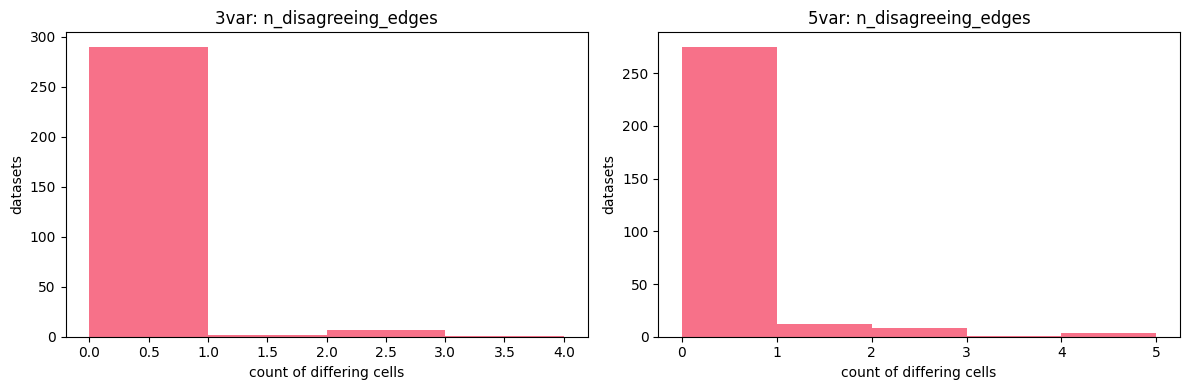

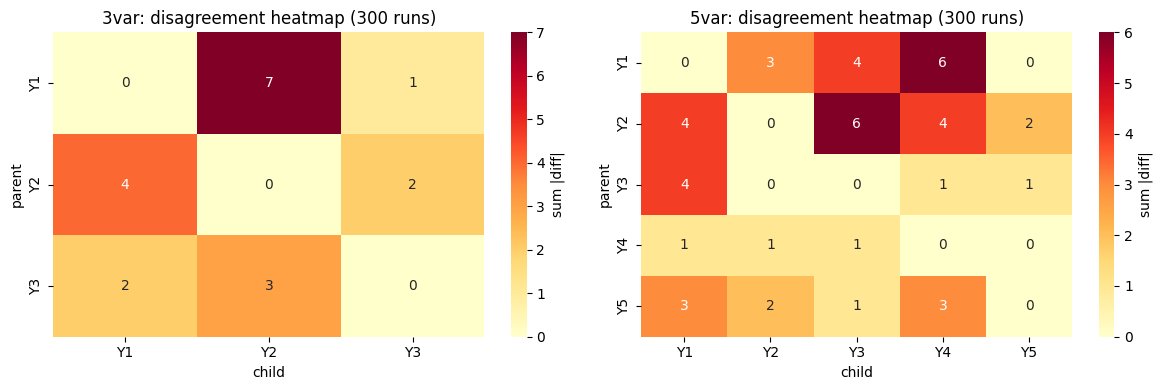

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, dag in zip(axes, DAGS):
    subset = diff_summary[diff_summary["dag"] == dag]
    ax.hist(subset["n_disagreeing_edges"], bins=range(0, subset["n_disagreeing_edges"].max() + 2))
    ax.set_title(f"{dag}: n_disagreeing_edges")
    ax.set_xlabel("count of differing cells")
    ax.set_ylabel("datasets")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, dag in zip(axes, DAGS):
    node_names = NODE_NAMES[dag]
    hm = pd.DataFrame(
        heatmap_accum[dag],
        index=node_names,
        columns=node_names,
    )
    sns.heatmap(hm, annot=True, fmt="d", cmap="YlOrRd", ax=ax, cbar_kws={"label": "sum |diff|"})
    ax.set_title(f"{dag}: disagreement heatmap (300 runs)")
    ax.set_xlabel("child")
    ax.set_ylabel("parent")

plt.tight_layout()
plt.show()

## 3. Metrics agreement

Join `python_metrics.csv` and `r_metrics.csv` on `(dag, dataset_id, metric)`.

In [5]:
merged = py_metrics.merge(
    r_metrics,
    on=["dag", "dataset_id", "metric"],
    suffixes=("_py", "_r"),
)

eval_metrics = [
    "accuracy", "sensitivity", "specificity", "ppv", "npv", "directional_accuracy"
]

for dag in DAGS:
    print(f"\n=== {dag} ===")
    subset = merged[(merged["dag"] == dag) & (merged["metric"].isin(eval_metrics))]
    summary = (
        subset.groupby("metric")[["value_py", "value_r"]]
        .agg(["mean", "std"])
        .round(4)
    )
    display(summary)

    time_subset = merged[(merged["dag"] == dag) & (merged["metric"] == "computation_time")]
    print(
        f"Mean time (py): {time_subset['value_py'].mean():.3f}s  "
        f"Mean time (r):  {time_subset['value_r'].mean():.3f}s"
    )


=== 3var ===


value_py         value_r        
                         mean     std    mean     std
metric                                               
accuracy               0.9700  0.1133  0.9667  0.1173
directional_accuracy   0.8900  0.2304  0.8883  0.2350
npv                    0.9659  0.1566  0.9623  0.1615
ppv                    0.9839  0.0808  0.9828  0.0828
sensitivity            0.9750  0.1092  0.9717  0.1158
specificity            0.9600  0.1963  0.9567  0.2039

Mean time (py): 2.527s  Mean time (r):  2.887s

=== 5var ===


value_py         value_r        
                         mean     std    mean     std
metric                                               
accuracy               0.9577  0.0796  0.9607  0.0766
directional_accuracy   0.9080  0.1428  0.9080  0.1410
npv                    0.9731  0.0757  0.9720  0.0759
ppv                    0.9530  0.0933  0.9585  0.0878
sensitivity            0.9707  0.0846  0.9693  0.0857
specificity            0.9447  0.1122  0.9520  0.1026

Mean time (py): 18.666s  Mean time (r):  7.865s


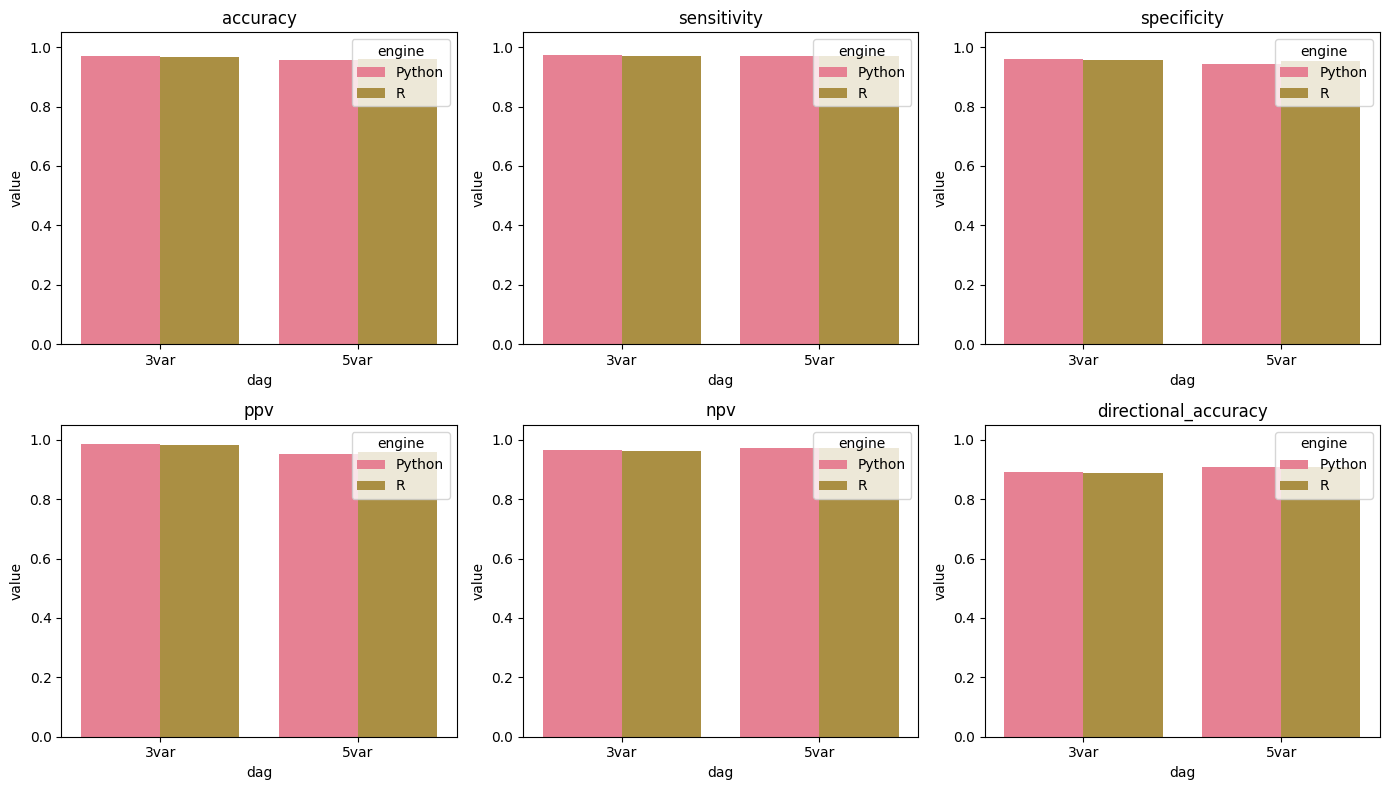

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, metric in zip(axes, eval_metrics):
    subset = merged[merged["metric"] == metric]
    plot_df = subset.groupby("dag")[["value_py", "value_r"]].mean().reset_index()
    plot_df = plot_df.melt(id_vars="dag", var_name="engine", value_name="value")
    plot_df["engine"] = plot_df["engine"].map({"value_py": "Python", "value_r": "R"})
    sns.barplot(data=plot_df, x="dag", y="value", hue="engine", ax=ax)
    ax.set_title(metric)
    ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

## 4. Summary table (one row per DAG)

In [7]:
def metric_mean(metrics_df, dag, metric):
    return metrics_df[(metrics_df["dag"] == dag) & (metrics_df["metric"] == metric)]["value"].mean()

summary_rows = []
for dag in DAGS:
    dag_diff = diff_summary[diff_summary["dag"] == dag]
    summary_rows.append(
        {
            "dag": dag,
            "pct_exact_match": dag_diff["exact_match"].mean() * 100,
            "mean_SHD": dag_diff["n_disagreeing_edges"].mean(),
            "mean_accuracy_py": metric_mean(py_metrics, dag, "accuracy"),
            "mean_accuracy_r": metric_mean(r_metrics, dag, "accuracy"),
            "mean_time_py": metric_mean(py_metrics, dag, "computation_time"),
            "mean_time_r": metric_mean(r_metrics, dag, "computation_time"),
        }
    )

summary_table = pd.DataFrame(summary_rows)
display(summary_table.round(4))

,dag,pct_exact_match,mean_SHD,mean_accuracy_py,mean_accuracy_r,mean_time_py,mean_time_r
0,3var,96.6667,0.0633,0.9700,0.9667,2.5267,2.8872
1,5var,91.6667,0.1567,0.9577,0.9607,18.6658,7.8655
